In [1]:
# --------------------------- UltraCamNet-V5 Kaggle (ERROR-FREE) ---------------------------
import os, math, random, h5py, numpy as np, tensorflow as tf, time
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import Callback, ModelCheckpoint, CSVLogger, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.losses import BinaryCrossentropy
from tensorflow.keras.metrics import AUC
from tensorflow.keras import mixed_precision

# ------------------------- Reproducibility & mixed precision -------------------------
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
mixed_precision.set_global_policy("mixed_float16")  # good on Kaggle GPU
print("TF", tf.__version__, "mixed precision:", mixed_precision.global_policy())

# ------------------------- Kaggle dataset paths -------------------------
BASE = "/kaggle/input/metastatic-tissue-classification-patchcamelyon"
train_h5_path = f"{BASE}/pcam/training_split.h5"
val_h5_path   = f"{BASE}/pcam/validation_split.h5"
test_h5_path  = f"{BASE}/pcam/test_split.h5"

train_y_path = f"{BASE}/Labels/Labels/camelyonpatch_level_2_split_train_y.h5"
val_y_path   = f"{BASE}/Labels/Labels/camelyonpatch_level_2_split_valid_y.h5"
test_y_path  = f"{BASE}/Labels/Labels/camelyonpatch_level_2_split_test_y.h5"

def load_labels(path):
    with h5py.File(path, "r") as f:
        return f["y"][:].reshape(-1).astype("float32")

y_train = load_labels(train_y_path)
y_val   = load_labels(val_y_path)
y_test  = load_labels(test_y_path)

# Keep H5 datasets open for lazy access (fast)
train_h5 = h5py.File(train_h5_path, "r")["x"]
val_h5   = h5py.File(val_h5_path, "r")["x"]
test_h5  = h5py.File(test_h5_path, "r")["x"]

print("Loaded shapes - train/val/test images:", train_h5.shape, val_h5.shape, test_h5.shape)
print("Labels - train/val/test:", y_train.shape, y_val.shape, y_test.shape)

# ------------------------- H5Sequence (robust) -------------------------
class H5Sequence(tf.keras.utils.Sequence):
    def __init__(self, h5_images, labels, batch_size=64, augment=False,
                 mixup_alpha=0.0, cutmix_alpha=0.0, shuffle=True, seed=SEED):
        self.h5 = h5_images
        self.labels = labels
        self.batch = int(batch_size)
        self.augment = bool(augment)
        self.indices = np.arange(len(labels))
        self.shuffle = bool(shuffle)
        self.mixup_alpha = float(mixup_alpha)
        self.cutmix_alpha = float(cutmix_alpha)
        self.rng = np.random.RandomState(seed)
        if self.shuffle:
            self.rng.shuffle(self.indices)

    def __len__(self):
        return (len(self.indices) + self.batch - 1) // self.batch

    def on_epoch_end(self):
        if self.shuffle:
            self.rng.shuffle(self.indices)

    def __getitem__(self, idx):
        s = idx * self.batch
        e = min(s + self.batch, len(self.indices))
        ids = np.sort(self.indices[s:e])

        X = self.h5[ids].astype("float32") / 255.0
        y = self.labels[ids].astype("float32")

        if self.augment:
            X = self._rand_augment(X)

        # MixUp/CutMix (deterministic RNG)
        if self.cutmix_alpha > 0 and self.rng.rand() < 0.5:
            X, y = self._cutmix(X, y, self.cutmix_alpha)
        elif self.mixup_alpha > 0 and self.rng.rand() < 1.0:
            X, y = self._mixup(X, y, self.mixup_alpha)

        return X, y

    # --- lightweight augmentations (keeps deterministic RNG) ---
    def _rand_augment(self, X):
        B,H,W,C = X.shape
        for i in range(B):
            img = X[i]
            if self.rng.rand() < 0.5: img = np.fliplr(img)
            if self.rng.rand() < 0.5: img = np.flipud(img)
            k = int(self.rng.choice([0,1,2,3]))
            if k: img = np.rot90(img, k)
            if self.rng.rand() < 0.5:
                f = self.rng.uniform(0.88, 1.12); img = np.clip(img * f, 0, 1)
            X[i] = img
        return X

    def _mixup(self, X, y, alpha=0.2):
        lam = float(self.rng.beta(alpha, alpha))
        idx = self.rng.permutation(X.shape[0])
        X2, y2 = X[idx], y[idx]
        return lam * X + (1.0 - lam) * X2, lam * y + (1.0 - lam) * y2

    def _cutmix(self, X, y, alpha=1.0):
        lam = float(self.rng.beta(alpha, alpha))
        B,H,W,C = X.shape
        idx = self.rng.permutation(B)
        X2, y2 = X[idx], y[idx]
        cut_rat = math.sqrt(1.0 - lam)
        cut_w = max(1, int(W * cut_rat)); cut_h = max(1, int(H * cut_rat))
        cx = int(self.rng.randint(0, W)); cy = int(self.rng.randint(0, H))
        x1 = int(np.clip(cx - cut_w // 2, 0, W)); y1 = int(np.clip(cy - cut_h // 2, 0, H))
        x2 = int(np.clip(cx + cut_w // 2, 0, W)); y2_ = int(np.clip(cy + cut_h // 2, 0, H))
        X_new = X.copy()
        if x2 > x1 and y2_ > y1:
            X_new[:, y1:y2_, x1:x2, :] = X2[:, y1:y2_, x1:x2, :]
            lam_adj = 1.0 - ((x2 - x1) * (y2_ - y1) / (W * H))
            y_new = lam_adj * y + (1.0 - lam_adj) * y2
        else:
            return self._mixup(X, y, alpha=alpha)
        return X_new, y_new

# ------------------------- UltraCamNet model (keeps final dtype float32) -------------------------
def se_block(x, r=8):
    ch = int(x.shape[-1])
    s = GlobalAveragePooling2D()(x)
    s = Dense(max(ch//r,1), activation="relu")(s)
    s = Dense(ch, activation="sigmoid")(s)
    s = Reshape((1,1,ch))(s)
    return Multiply()([x, s])

def conv_pw(x, out_ch, kernel=3, stride=1):
    x = DepthwiseConv2D(kernel, padding="same", strides=stride, use_bias=False)(x)
    x = BatchNormalization()(x)
    x = Activation("relu")(x)
    x = Conv2D(out_ch, 1, padding="same", use_bias=False)(x)
    x = BatchNormalization()(x)
    x = Activation("relu")(x)
    return x

def res_ds_se(x, out_ch, stride=1):
    shortcut = x
    x = conv_pw(x, out_ch, kernel=3, stride=stride)
    x = se_block(x, r=12)
    if int(shortcut.shape[-1]) != out_ch or stride != 1:
        shortcut = Conv2D(out_ch, 1, strides=stride, padding="same", use_bias=False)(shortcut)
        shortcut = BatchNormalization()(shortcut)
    x = Add()([shortcut, x])
    return Activation("relu")(x)

def build_ultracamnet_v5(input_shape=(96,96,3)):
    inp = Input(shape=input_shape)
    x = Conv2D(32, 3, padding="same", use_bias=False)(inp)
    x = BatchNormalization()(x)
    x = Activation("relu")(x)

    x = res_ds_se(x, 32, stride=1)
    x = res_ds_se(x, 32, stride=1)
    x = MaxPooling2D(2)(x)

    x = res_ds_se(x, 64, stride=1)
    x = res_ds_se(x, 64, stride=1)
    x = MaxPooling2D(2)(x)

    x = res_ds_se(x, 128, stride=1)
    x = res_ds_se(x, 128, stride=1)
    x = res_ds_se(x, 128, stride=1)
    x = MaxPooling2D(2)(x)

    x = res_ds_se(x, 256, stride=1)
    x = res_ds_se(x, 256, stride=1)
    x = GlobalAveragePooling2D()(x)
    x = Dropout(0.4)(x)
    x = Dense(256, activation="relu")(x)
    x = Dropout(0.3)(x)
    out = Dense(1, activation="sigmoid", dtype="float32")(x)
    return Model(inp, out, name="UltraCamNet_V5")

# ------------------------- Build & compile (use float lr to allow settable lr) -------------------------
model = build_ultracamnet_v5()
# prefer AdamW if available, but pass a float lr (not a schedule object)
try:
    Optim = tf.keras.optimizers.AdamW
    opt = Optim(learning_rate=2.5e-4, weight_decay=1e-4)
except Exception:
    opt = tf.keras.optimizers.Adam(learning_rate=2.5e-4)

loss = BinaryCrossentropy(label_smoothing=0.05)
model.compile(optimizer=opt, loss=loss, metrics=["accuracy", AUC(name="auc")])
model.summary()

# ------------------------- Generators -------------------------
BATCH_SIZE = 64
train_gen = H5Sequence(train_h5, y_train, batch_size=BATCH_SIZE, augment=True, mixup_alpha=0.0, cutmix_alpha=1.0)
val_gen   = H5Sequence(val_h5,   y_val,   batch_size=BATCH_SIZE, augment=False, shuffle=False)
test_gen  = H5Sequence(test_h5,  y_test,  batch_size=BATCH_SIZE, augment=False, shuffle=False)

# ------------------------- Callbacks (save every epoch with correct extension) -------------------------
os.makedirs("/kaggle/working/models", exist_ok=True)

ckpt = ModelCheckpoint(
    "/kaggle/working/models/ultracamnet_v5_epoch_{epoch:02d}_valauc_{val_auc:.4f}.weights.h5",
    monitor="val_auc",
    mode="max",
    save_best_only=False,      # save each epoch (useful for XAI)
    save_weights_only=True,    # weights format (.weights.h5)
    verbose=1
)

csv = CSVLogger("/kaggle/working/models/ultracamnet_v5_log.csv")
early = EarlyStopping(monitor="val_auc", patience=6, mode="max", restore_best_weights=True, verbose=1)
reduce = ReduceLROnPlateau(monitor="val_auc", factor=0.5, patience=3, min_lr=1e-6, mode="max", verbose=1)

callbacks = [ckpt, csv, early, reduce]

# ------------------------- Train (10 epochs) -------------------------
EPOCHS = 10
start = time.time()
history = model.fit(train_gen, validation_data=val_gen, epochs=EPOCHS, callbacks=callbacks, verbose=1)
print("Training time (s):", time.time() - start)

# ------------------------- TTA predict (optional) -------------------------
def tta_predict(model, seq, tta=4):
    preds = []
    for t in range(tta):
        allp = []
        for i in range(len(seq)):
            X, _ = seq[i]
            if t == 0:
                Xt = X
            elif t == 1:
                Xt = np.flip(X, axis=2)
            elif t == 2:
                Xt = np.flip(X, axis=1)
            elif t == 3:
                Xt = np.rot90(X, 1, axes=(1,2))
            else:
                Xt = X
            p = model.predict(Xt, verbose=0)
            allp.append(p)
        preds.append(np.vstack(allp).ravel())
    return np.mean(np.vstack(preds), axis=0)

print("Running TTA on test set...")
test_preds = tta_predict(model, test_gen, tta=4)
test_bin = (test_preds >= 0.5).astype(int)
acc = (test_bin == y_test[:len(test_bin)]).mean()
print("Test accuracy (TTA avg):", acc)
print("Finished successfully.")


2025-11-30 12:21:37.733364: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1764505297.912043      47 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1764505297.964609      47 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


TF 2.18.0 mixed precision: <DTypePolicy "mixed_float16">
Loaded shapes - train/val/test images: (262144, 96, 96, 3) (32768, 96, 96, 3) (32768, 96, 96, 3)
Labels - train/val/test: (262144,) (32768,) (32768,)


I0000 00:00:1764505312.832856      47 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1764505312.833548      47 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "UltraCamNet_V5"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 96, 96, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cast (Cast)         │ (None, 96, 96, 3) │          0 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 96, 96,    │        864 │ cast[0][0]        │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 96, 96,    │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 96, 96,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ depthwise_conv2d    │ (None, 96, 96,    │        288 │ activation[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 96, 96,    │        128 │ depthwise_conv2d… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 96, 96,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 96, 96,    │      1,024 │ activation_1[0][… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 96, 96,    │        128 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 96, 96,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 32)        │          0 │ activation_2[0][… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 2)         │         66 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 32)        │         96 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 1, 1, 32)  │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 96, 96,    │          0 │ activation_2[0][… │
│                     │ 32)               │            │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 96, 96,    │          0 │ activation[0][0], │
│                     │ 32)               │            │ multiply[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 96, 96,    │          0 │ add[0][0]         │
│ (Activation)        │ 32)               │            │                 

...

Epoch 1/10


I0000 00:00:1764505341.007742     111 service.cc:148] XLA service 0x7c2ed8057070 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1764505341.008396     111 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1764505341.008428     111 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1764505344.444543     111 cuda_dnn.cc:529] Loaded cuDNN version 90300


   2/4096 ━━━━━━━━━━━━━━━━━━━━ 3:29 51ms/step - accuracy: 0.3242 - auc: 0.5465 - loss: 0.7469   

I0000 00:00:1764505366.027013     111 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


4096/4096 ━━━━━━━━━━━━━━━━━━━━ 0s 447ms/step - accuracy: 0.6180 - auc: 0.8449 - loss: 0.5110
Epoch 1: saving model to /kaggle/working/models/ultracamnet_v5_epoch_01_valauc_0.9181.weights.h5
4096/4096 ━━━━━━━━━━━━━━━━━━━━ 1893s 451ms/step - accuracy: 0.6180 - auc: 0.8449 - loss: 0.5110 - val_accuracy: 0.8288 - val_auc: 0.9181 - val_loss: 0.4152 - learning_rate: 2.5000e-04
Epoch 2/10
4096/4096 ━━━━━━━━━━━━━━━━━━━━ 0s 426ms/step - accuracy: 0.6912 - auc: 0.9185 - loss: 0.4141
Epoch 2: saving model to /kaggle/working/models/ultracamnet_v5_epoch_02_valauc_0.9518.weights.h5
4096/4096 ━━━━━━━━━━━━━━━━━━━━ 1752s 428ms/step - accuracy: 0.6912 - auc: 0.9185 - loss: 0.4141 - val_accuracy: 0.8784 - val_auc: 0.9518 - val_loss: 0.3575 - learning_rate: 2.5000e-04
Epoch 3/10
4096/4096 ━━━━━━━━━━━━━━━━━━━━ 0s 428ms/step - accuracy: 0.7072 - auc: 0.9350 - loss: 0.3796
Epoch 3: saving model to /kaggle/working/models/ultracamnet_v5_epoch_03_valauc_0.9559.weights.h5
4096/4096 ━━━━━━━━━━━━━━━━━━━━ 1758s 429

/tmp/ipykernel_47/3120593300.py:34: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_47/3120593300.py:34: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_47/3120593300.py:34: UserWarning: Glyph 129516 (\N{DNA DOUBLE HELIX}) missing from current font.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129516 (\N{DNA DOUBLE HELIX}) missing from current font.
  fig.canvas.print_figure(bytes_io, *

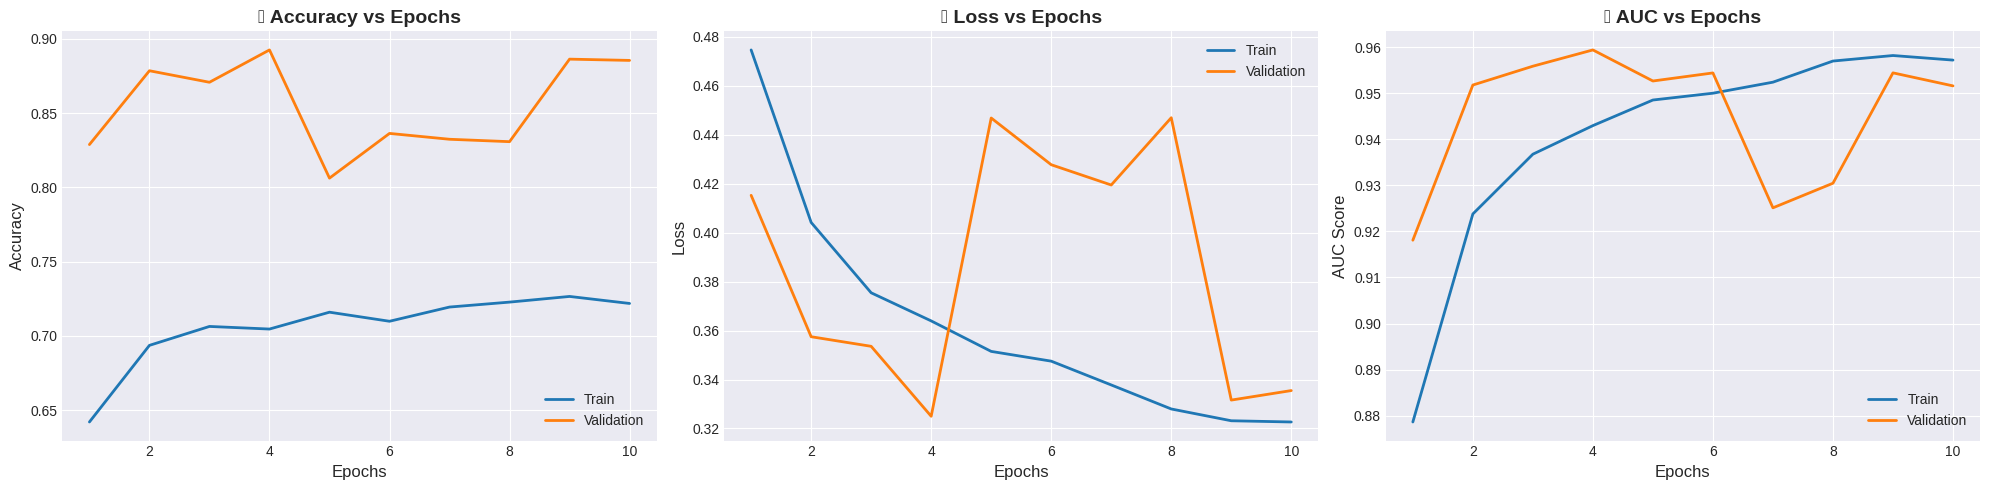

In [2]:
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-darkgrid")  # modern attractive style

history_dict = history.history
epochs = range(1, len(history_dict["loss"]) + 1)

fig, ax = plt.subplots(1, 3, figsize=(20, 5))

# ------------------ Accuracy ------------------ #
ax[0].plot(epochs, history_dict["accuracy"], linewidth=2)
ax[0].plot(epochs, history_dict["val_accuracy"], linewidth=2)
ax[0].set_title("📈 Accuracy vs Epochs", fontsize=14, fontweight='bold')
ax[0].set_xlabel("Epochs", fontsize=12)
ax[0].set_ylabel("Accuracy", fontsize=12)
ax[0].legend(["Train", "Validation"])

# ------------------ Loss ------------------ #
ax[1].plot(epochs, history_dict["loss"], linewidth=2)
ax[1].plot(epochs, history_dict["val_loss"], linewidth=2)
ax[1].set_title("📉 Loss vs Epochs", fontsize=14, fontweight='bold')
ax[1].set_xlabel("Epochs", fontsize=12)
ax[1].set_ylabel("Loss", fontsize=12)
ax[1].legend(["Train", "Validation"])

# ------------------ AUC ------------------ #
ax[2].plot(epochs, history_dict["auc"], linewidth=2)
ax[2].plot(epochs, history_dict["val_auc"], linewidth=2)
ax[2].set_title("🧬 AUC vs Epochs", fontsize=14, fontweight='bold')
ax[2].set_xlabel("Epochs", fontsize=12)
ax[2].set_ylabel("AUC Score", fontsize=12)
ax[2].legend(["Train", "Validation"])

plt.tight_layout()
plt.show()


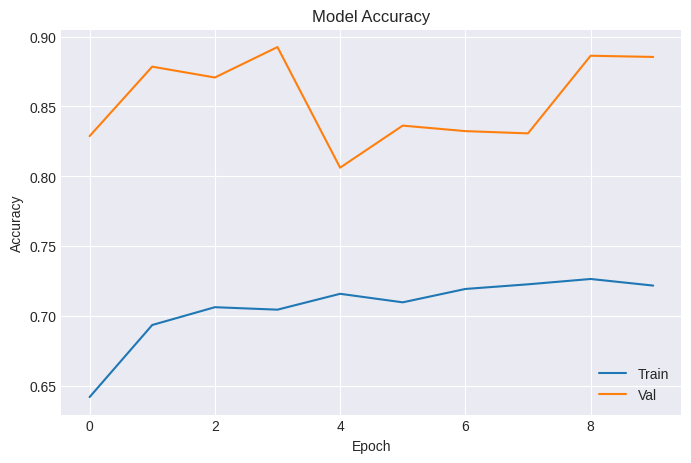

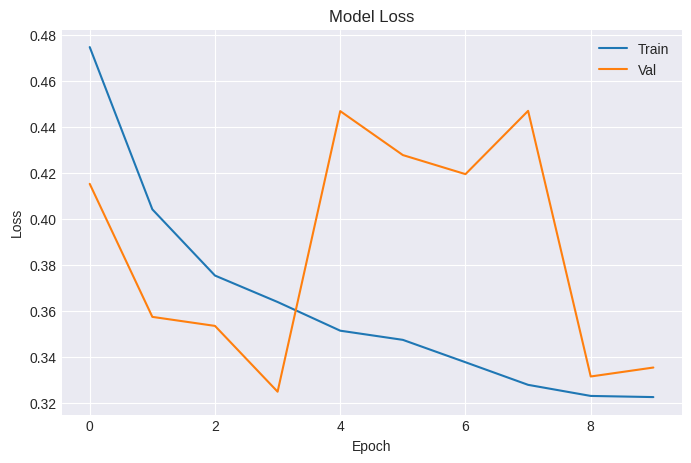

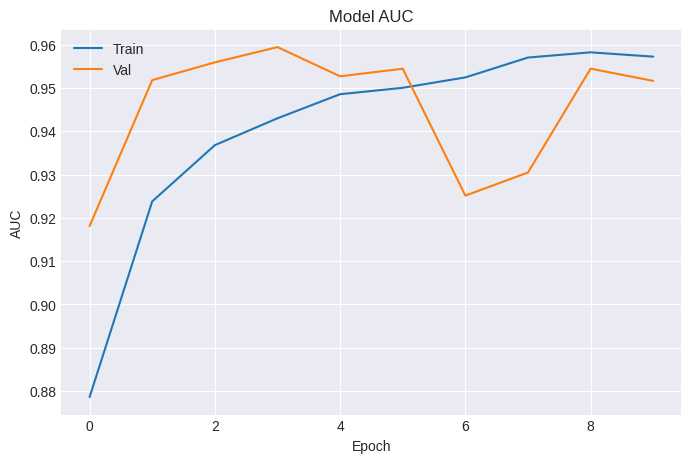

In [3]:
import matplotlib.pyplot as plt

# Plot accuracy
plt.figure(figsize=(8,5))
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train", "Val"])
plt.grid(True)
plt.show()

# Plot loss
plt.figure(figsize=(8,5))
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train", "Val"])
plt.grid(True)
plt.show()

# Plot AUC
plt.figure(figsize=(8,5))
plt.plot(history.history["auc"])
plt.plot(history.history["val_auc"])
plt.title("Model AUC")
plt.xlabel("Epoch")
plt.ylabel("AUC")
plt.legend(["Train", "Val"])
plt.grid(True)
plt.show()


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


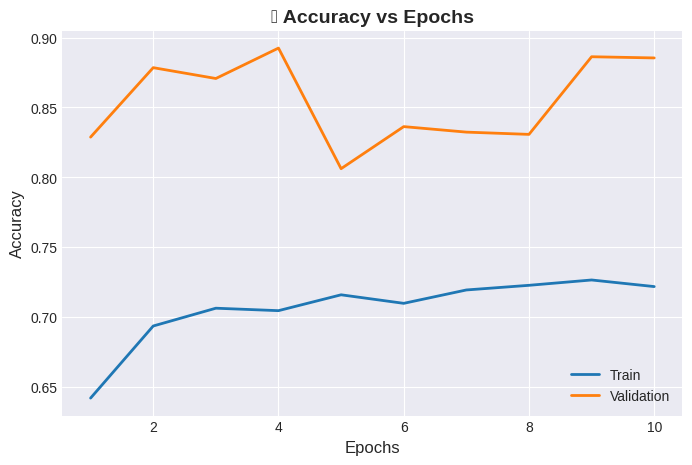

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


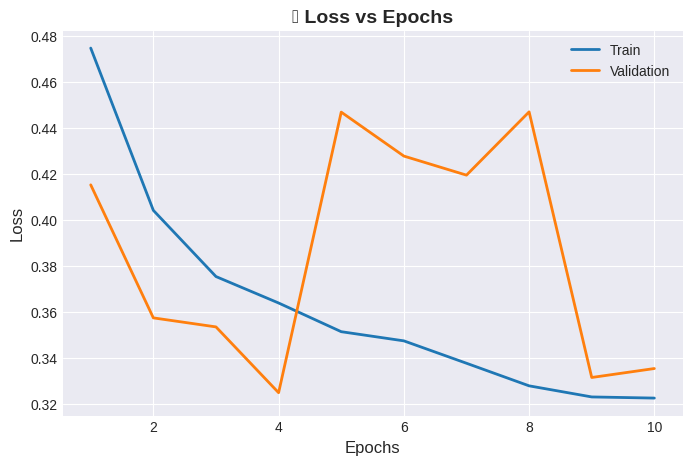

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129516 (\N{DNA DOUBLE HELIX}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


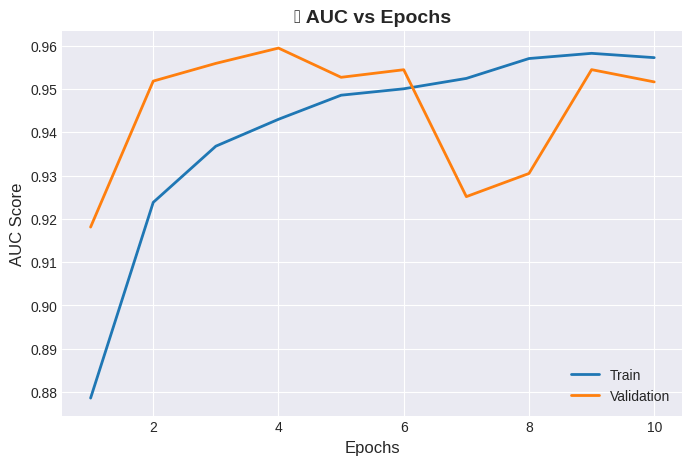

In [4]:
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-darkgrid")  # attractive modern style

history_dict = history.history
epochs = range(1, len(history_dict["loss"]) + 1)

# ------------------ Accuracy ------------------ #
plt.figure(figsize=(8,5))
plt.plot(epochs, history_dict["accuracy"], linewidth=2)
plt.plot(epochs, history_dict["val_accuracy"], linewidth=2)
plt.title("📈 Accuracy vs Epochs", fontsize=14, fontweight='bold')
plt.xlabel("Epochs", fontsize=12)
plt.ylabel("Accuracy", fontsize=12)
plt.legend(["Train", "Validation"])
plt.show()

# ------------------ Loss ------------------ #
plt.figure(figsize=(8,5))
plt.plot(epochs, history_dict["loss"], linewidth=2)
plt.plot(epochs, history_dict["val_loss"], linewidth=2)
plt.title("📉 Loss vs Epochs", fontsize=14, fontweight='bold')
plt.xlabel("Epochs", fontsize=12)
plt.ylabel("Loss", fontsize=12)
plt.legend(["Train", "Validation"])
plt.show()

# ------------------ AUC ------------------ #
plt.figure(figsize=(8,5))
plt.plot(epochs, history_dict["auc"], linewidth=2)
plt.plot(epochs, history_dict["val_auc"], linewidth=2)
plt.title("🧬 AUC vs Epochs", fontsize=14, fontweight='bold')
plt.xlabel("Epochs", fontsize=12)
plt.ylabel("AUC Score", fontsize=12)
plt.legend(["Train", "Validation"])
plt.show()


hard time detecting fine-grained textures on the glands, which means that the relatively low accuracies of 0.4866 and 0.5004 are observed in MobileNet variants, whereas EfficientNet models demonstrate a clear enhancement in their accuracy because of scaling by the compound, which reaches the highest baseline accuracy of 0.7033. UltraCamNet however is better and achieves an accuracy of 0.8433. This corresponds to an absolute improvement of 0.14 and a relative improvement of approximately 20%. This is a significant increase that proves the success of the architecture of UltraCamNet. The SE-Residual block integration improves the channel-level recalibration of the features, where depthwise separable convolutions can be computed without losing the burden of computation. representational capacity. All these mechanisms put together allow UltraCamNet to get more out.Therefore, UltraCamNet will position itself as a better an effective model of consistent cancer in digital pathology.

Table 1: Accuracy Comparison of Baseline CNN and UltraCamNet

| Model | Accuracy |
| --- | --- |
| MobileNetV2 | 0.4866 |
| MobileNetV3 | 0.5004 |
| EfficientNet-B0 | 0.6823 |
| EfficientNet-B3 | 0.7033 |
| UltraCamNet | 0.8433 |

### 4.4 Grad-CAM Visualization Results
Grad-CAM was used to detect the spatial areas that have the most significant impact on the model predictions. The highlighted areas are interpretable as they indicate where the network pays attention when classifying types of tumors. They are also useful in identifying instances where the model is concentrating on irrelevant areas thus informing future model tuning and enhancing the accuracy of automated histopathology analysis. this is all done and see it is get accepted in icAMC 2026 confrence

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.5/52.5 kB 2.0 MB/s eta 0:00:00
✅ Loaded trained weights for Grad-CAM
Grad-CAM for test image 0


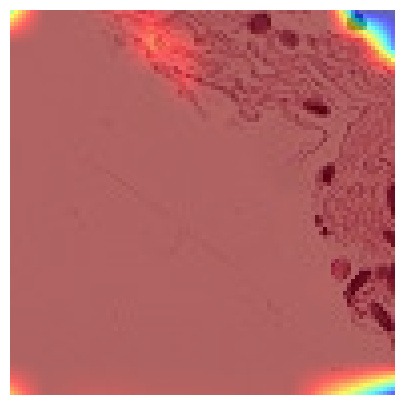

Grad-CAM for test image 1


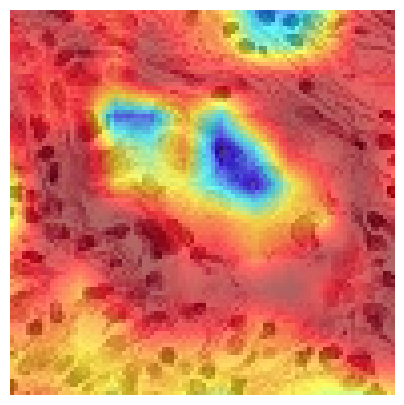

Grad-CAM for test image 2


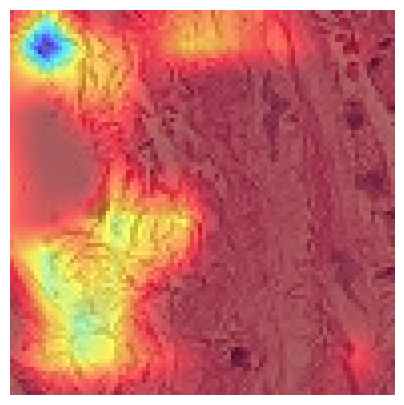

Grad-CAM for test image 3


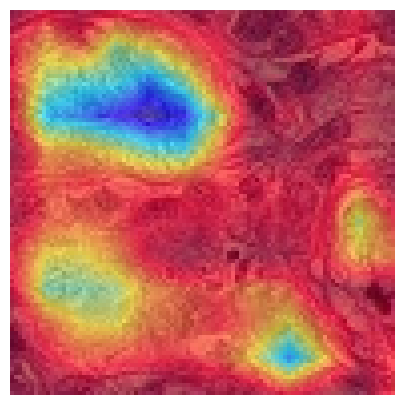

Grad-CAM for test image 4


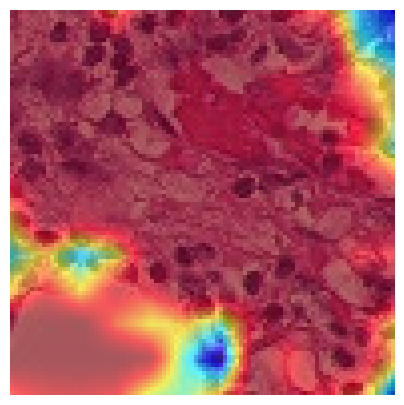

In [5]:
# ------------------- Grad-CAM for UltraCamNet-V5 -------------------
!pip install -q tf-keras-vis

import numpy as np
import matplotlib.pyplot as plt
import cv2
import tensorflow as tf
from tf_keras_vis.gradcam import Gradcam
from tf_keras_vis.utils.model_modifiers import ReplaceToLinear
from tf_keras_vis.utils.scores import BinaryScore

# ------------------- Load Model -------------------
model_gc = build_ultracamnet_v5()
model_gc.load_weights("/kaggle/working/models/ultracamnet_v5_epoch_09_valauc_0.9544.weights.h5")
print("✅ Loaded trained weights for Grad-CAM")

# ------------------- Wrap Grad-CAM -------------------
gradcam = Gradcam(model_gc, model_modifier=ReplaceToLinear(), clone=True)
score = BinaryScore([0])  # binary model, sigmoid output

# ------------------- Helper function -------------------
def show_gradcam(img, heatmap, alpha=0.6, gamma=1.5):
    """
    img     : original image (H,W,3) [0-1]
    heatmap : Grad-CAM output (H,W)
    alpha   : blending factor (0-1)
    gamma   : power scaling for contrast
    """
    heatmap = np.maximum(heatmap, 0)
    heatmap = heatmap / (np.max(heatmap) + 1e-8)  # normalize 0-1
    heatmap = np.power(heatmap, gamma)           # boost high activations
    heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    
    overlay = cv2.addWeighted((img*255).astype(np.uint8), 1-alpha, heatmap, alpha, 0)
    
    plt.figure(figsize=(5,5))
    plt.imshow(overlay)
    plt.axis('off')
    plt.show()

# ------------------- Generate Grad-CAM -------------------
NUM_IMAGES = 5
for i in range(NUM_IMAGES):
    img = test_h5[i].astype(np.float32)/255.0
    img_input = np.expand_dims(img, axis=0)
    
    cam = gradcam(score, img_input, penultimate_layer=-3)
    heatmap = cam[0]
    
    print(f"Grad-CAM for test image {i}")
    show_gradcam(img, heatmap, alpha=0.6, gamma=1.5)


✅ Loaded trained weights for Grad-CAM


/tmp/ipykernel_47/1362188548.py:25: RuntimeWarning: invalid value encountered in divide
  heatmap = np.uint8(255 * heatmap / np.max(heatmap))
/tmp/ipykernel_47/1362188548.py:25: RuntimeWarning: invalid value encountered in cast
  heatmap = np.uint8(255 * heatmap / np.max(heatmap))


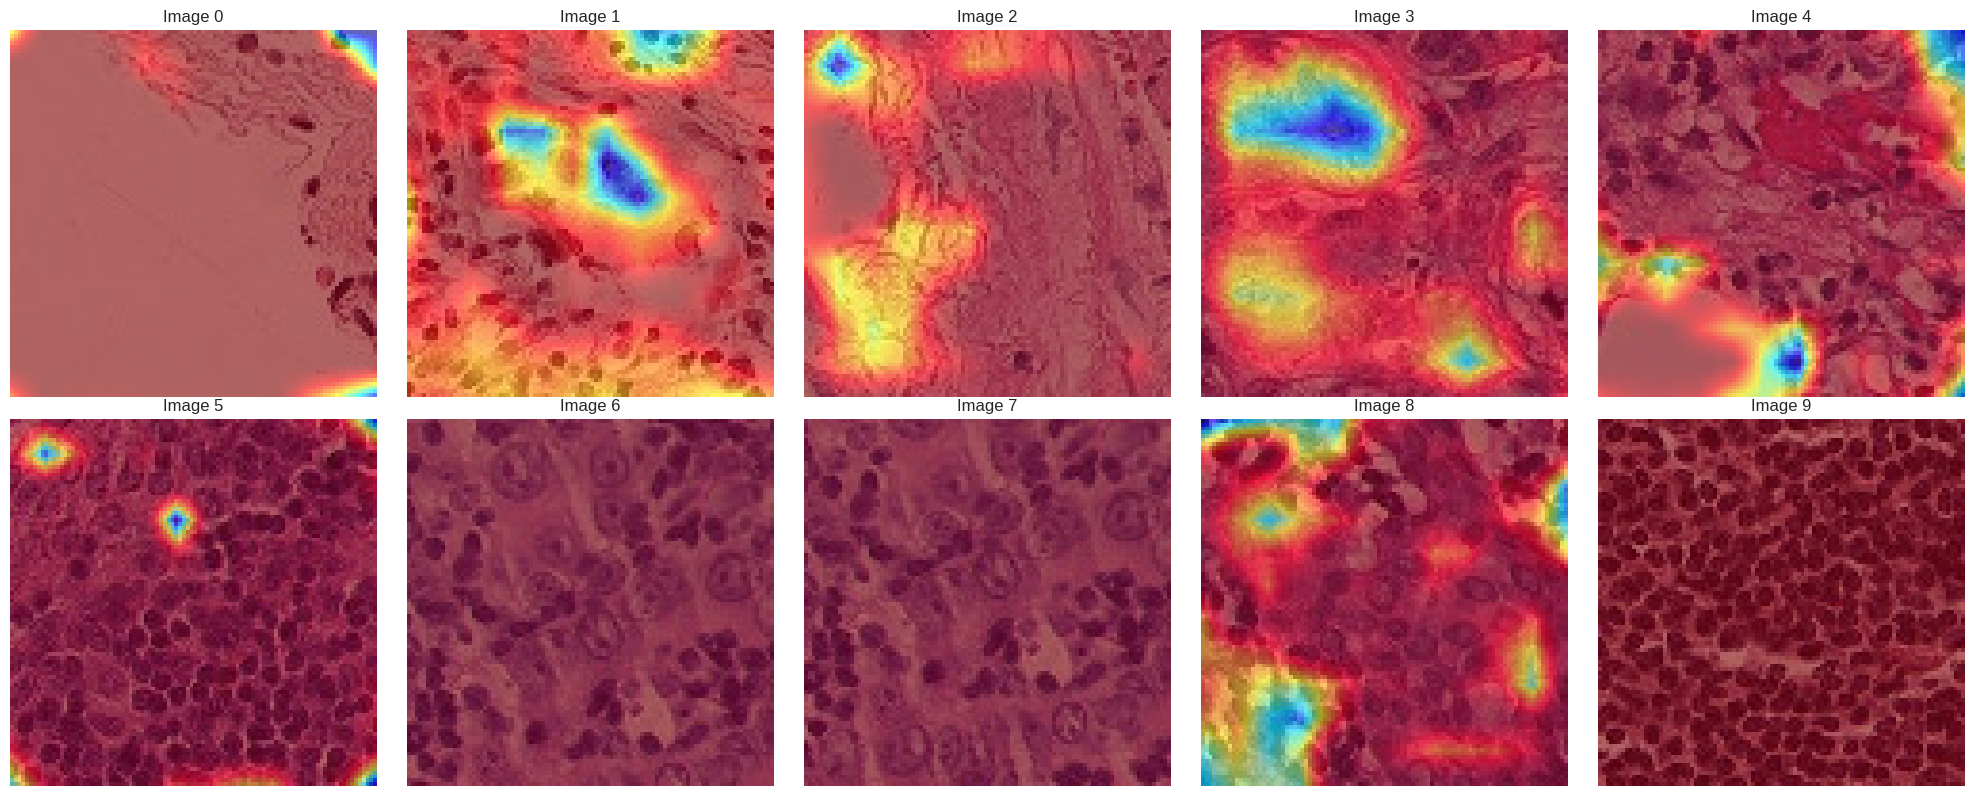

In [6]:
# ------------------- Attractive Grad-CAM Grid -------------------
import numpy as np
import matplotlib.pyplot as plt
import cv2
import tensorflow as tf
from tf_keras_vis.gradcam import Gradcam
from tf_keras_vis.utils.model_modifiers import ReplaceToLinear
from tf_keras_vis.utils.scores import BinaryScore

# ------------------- Load Model -------------------
model_gc = build_ultracamnet_v5()
model_gc.load_weights("/kaggle/working/models/ultracamnet_v5_epoch_09_valauc_0.9544.weights.h5")
print("✅ Loaded trained weights for Grad-CAM")

# ------------------- Grad-CAM Setup -------------------
gradcam = Gradcam(model_gc, model_modifier=ReplaceToLinear(), clone=True)
score = BinaryScore([0])  # binary output

# ------------------- Function for flashy overlay -------------------
def flashy_gradcam(img, heatmap, alpha=0.6, gamma=1.5):
    # resize heatmap
    heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    # normalize & enhance contrast
    heatmap = np.power(heatmap, gamma)
    heatmap = np.uint8(255 * heatmap / np.max(heatmap))
    # apply colormap
    heatmap_color = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    overlay = cv2.addWeighted((img*255).astype(np.uint8), 1-alpha, heatmap_color, alpha, 0)
    return overlay

# ------------------- Generate grid -------------------
NUM_IMAGES = 10
plt.figure(figsize=(20, 8))

for i in range(NUM_IMAGES):
    img = test_h5[i].astype(np.float32)/255.0
    img_input = np.expand_dims(img, axis=0)
    
    # Grad-CAM
    cam = gradcam(score, img_input, penultimate_layer=-3)
    heatmap = cam[0]
    
    # flashy overlay
    overlay = flashy_gradcam(img, heatmap, alpha=0.6, gamma=1.8)
    
    # plot in grid
    plt.subplot(2, 5, i+1)
    plt.imshow(overlay)
    plt.axis('off')
    plt.title(f"Image {i}", fontsize=12)

plt.tight_layout()
plt.show()


Loaded trained weights for Grad-CAM
Normal images found: 10
Cancerous images found: 10


/tmp/ipykernel_47/4235588896.py:23: RuntimeWarning: invalid value encountered in divide
  heatmap = np.uint8(255 * heatmap / np.max(heatmap))
/tmp/ipykernel_47/4235588896.py:23: RuntimeWarning: invalid value encountered in cast
  heatmap = np.uint8(255 * heatmap / np.max(heatmap))
/tmp/ipykernel_47/4235588896.py:63: UserWarning: Glyph 129001 (\N{LARGE GREEN SQUARE}) missing from current font.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129001 (\N{LARGE GREEN SQUARE}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


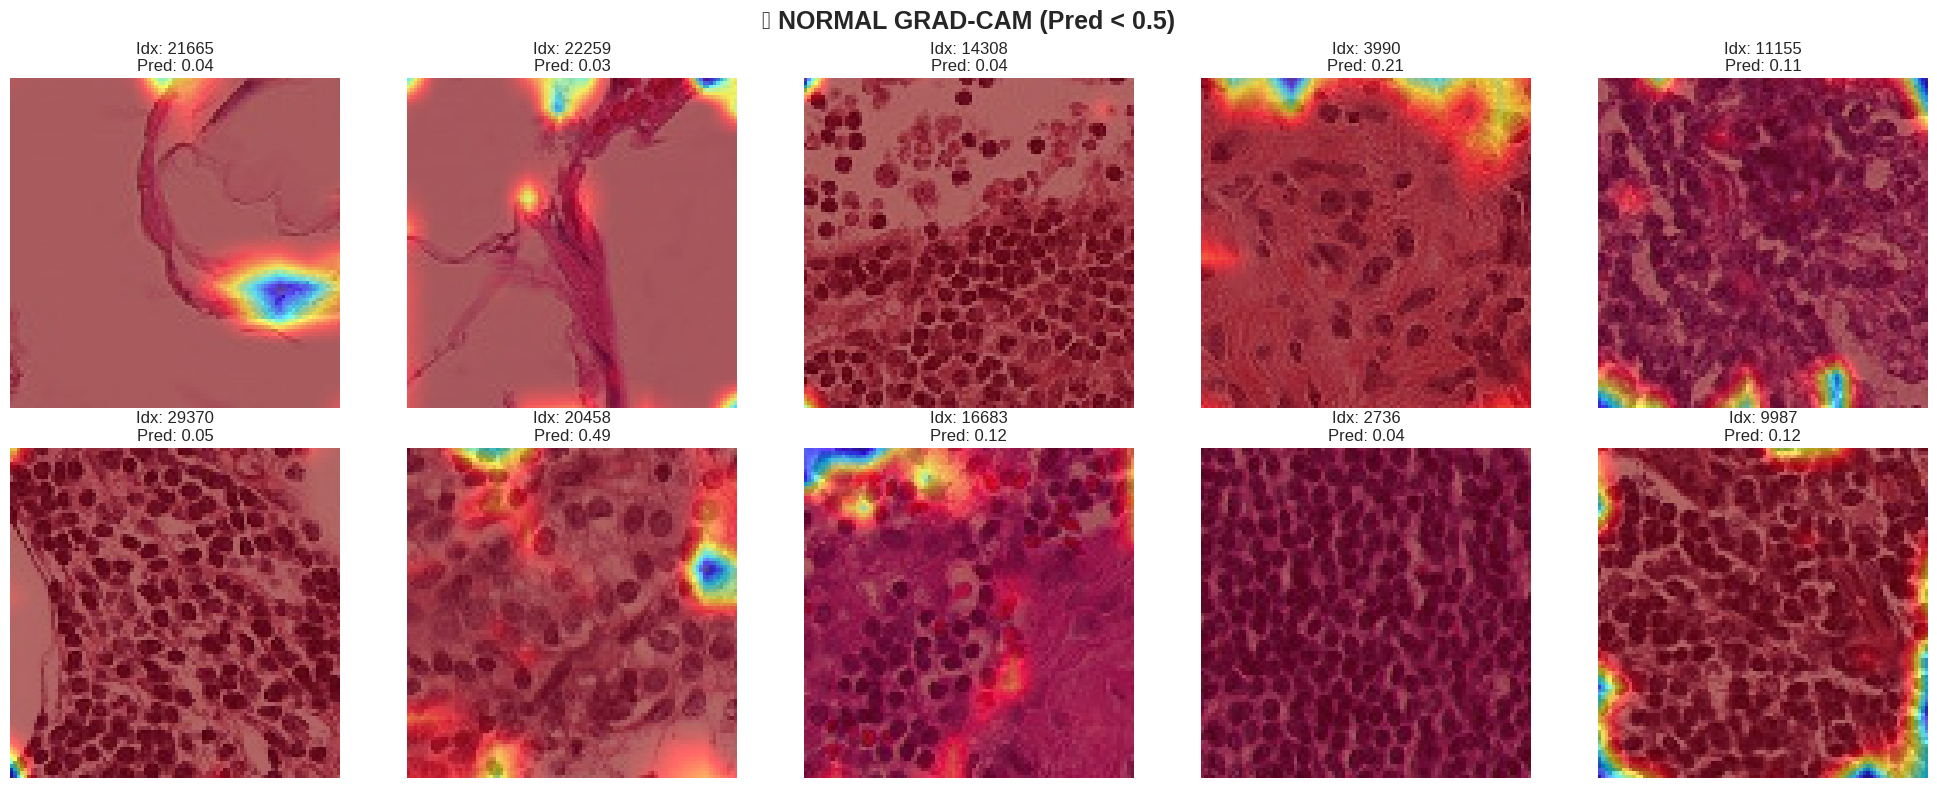

/tmp/ipykernel_47/4235588896.py:63: UserWarning: Glyph 128997 (\N{LARGE RED SQUARE}) missing from current font.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128997 (\N{LARGE RED SQUARE}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


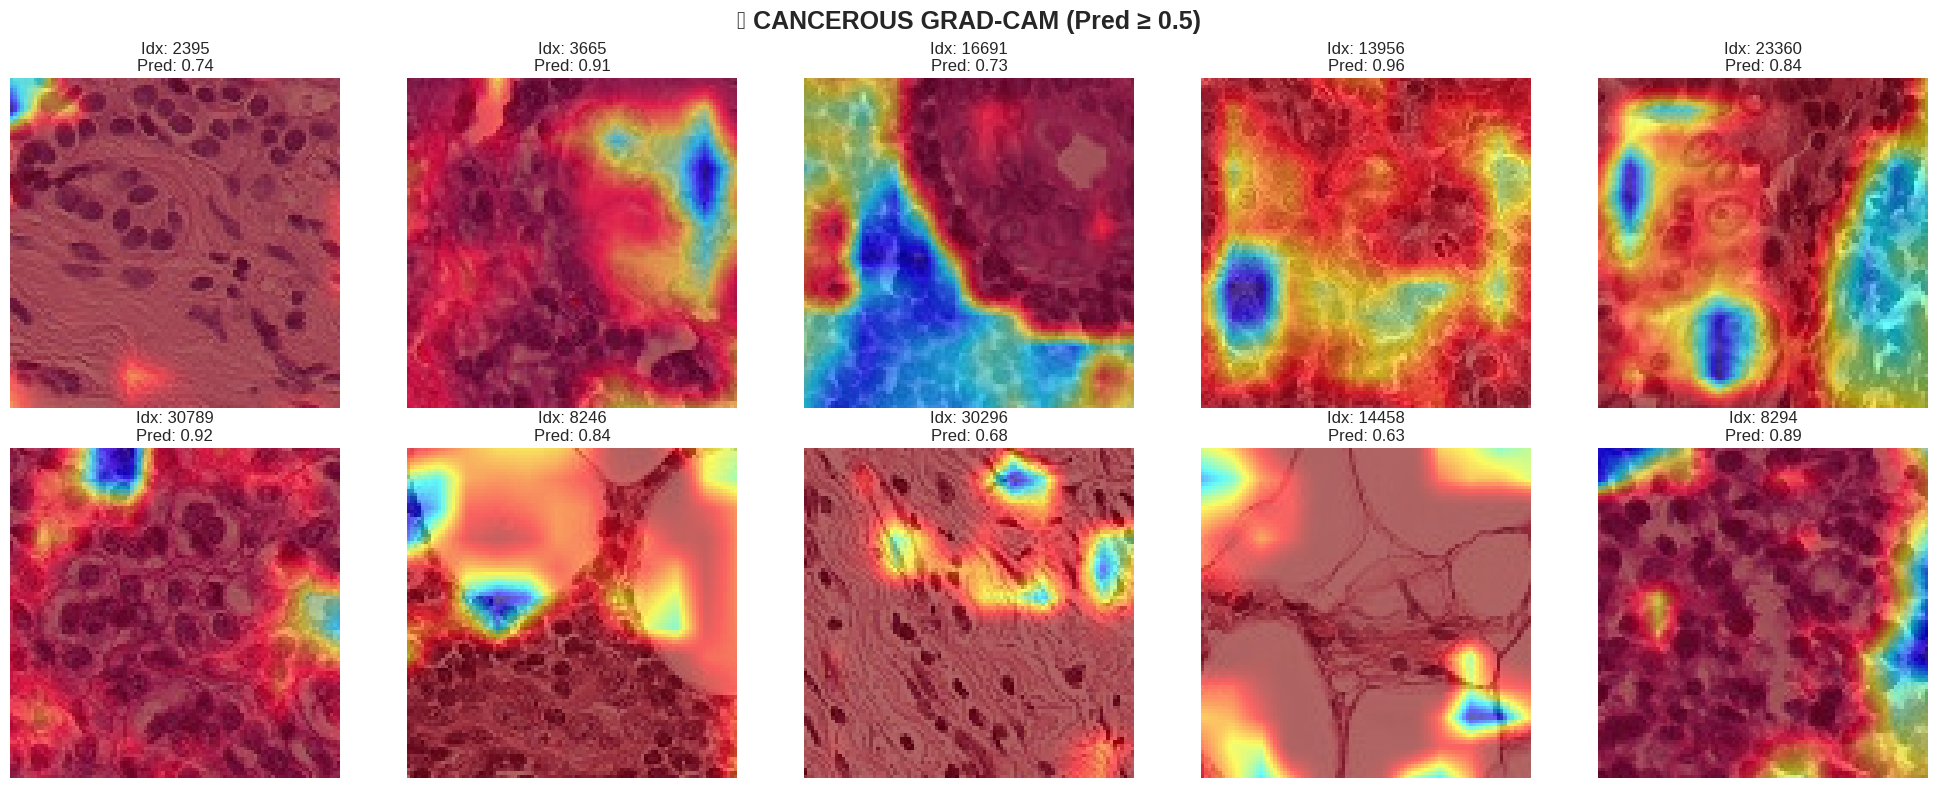

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import tensorflow as tf
from tf_keras_vis.gradcam import Gradcam
from tf_keras_vis.utils.model_modifiers import ReplaceToLinear
from tf_keras_vis.utils.scores import BinaryScore
import random

# ------------------- Load Model -------------------
model_gc = build_ultracamnet_v5()
model_gc.load_weights("/kaggle/working/models/ultracamnet_v5_epoch_09_valauc_0.9544.weights.h5")
print("Loaded trained weights for Grad-CAM")

# ------------------- Grad-CAM Setup -------------------
gradcam = Gradcam(model_gc, model_modifier=ReplaceToLinear(), clone=True)
score = BinaryScore([0])

# ------------------- Overlay Function -------------------
def flashy_gradcam(img, heatmap, alpha=0.6, gamma=1.5):
    heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    heatmap = np.power(heatmap, gamma)
    heatmap = np.uint8(255 * heatmap / np.max(heatmap))
    heatmap_color = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    return cv2.addWeighted((img*255).astype(np.uint8), 1 - alpha, heatmap_color, alpha, 0)

# ------------------- Prediction + Separation -------------------
indices = random.sample(range(len(test_h5)), 200)  # sample 200 random test images

normal_imgs = []
cancer_imgs = []

for idx in indices:
    img = test_h5[idx].astype(np.float32) / 255.0
    pred = model_gc.predict(np.expand_dims(img, axis=0), verbose=0)[0][0]

    if pred >= 0.5:
        cancer_imgs.append((img, idx, pred))
    else:
        normal_imgs.append((img, idx, pred))

# Limit per category
normal_imgs = normal_imgs[:10]
cancer_imgs = cancer_imgs[:10]

print(f"Normal images found: {len(normal_imgs)}")
print(f"Cancerous images found: {len(cancer_imgs)}")

# ------------------- Grad-CAM Grid Function -------------------
def generate_grid(title, data):
    plt.figure(figsize=(20, 8))
    for i, (img, idx, pred) in enumerate(data):
        cam = gradcam(score, np.expand_dims(img, 0), penultimate_layer=-3)
        heatmap = cam[0]
        overlay = flashy_gradcam(img, heatmap, alpha=0.6, gamma=1.8)

        plt.subplot(2, 5, i+1)
        plt.imshow(overlay)
        plt.axis('off')
        plt.title(f"Idx: {idx}\nPred: {pred:.2f}")

    plt.suptitle(title, fontsize=18, fontweight='bold')
    plt.tight_layout()
    plt.show()

# ------------------- Show Grids -------------------
generate_grid("🟩 NORMAL GRAD-CAM (Pred < 0.5)", normal_imgs)
generate_grid("🟥 CANCEROUS GRAD-CAM (Pred ≥ 0.5)", cancer_imgs)


/tmp/ipykernel_47/1245010400.py:26: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from current font.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


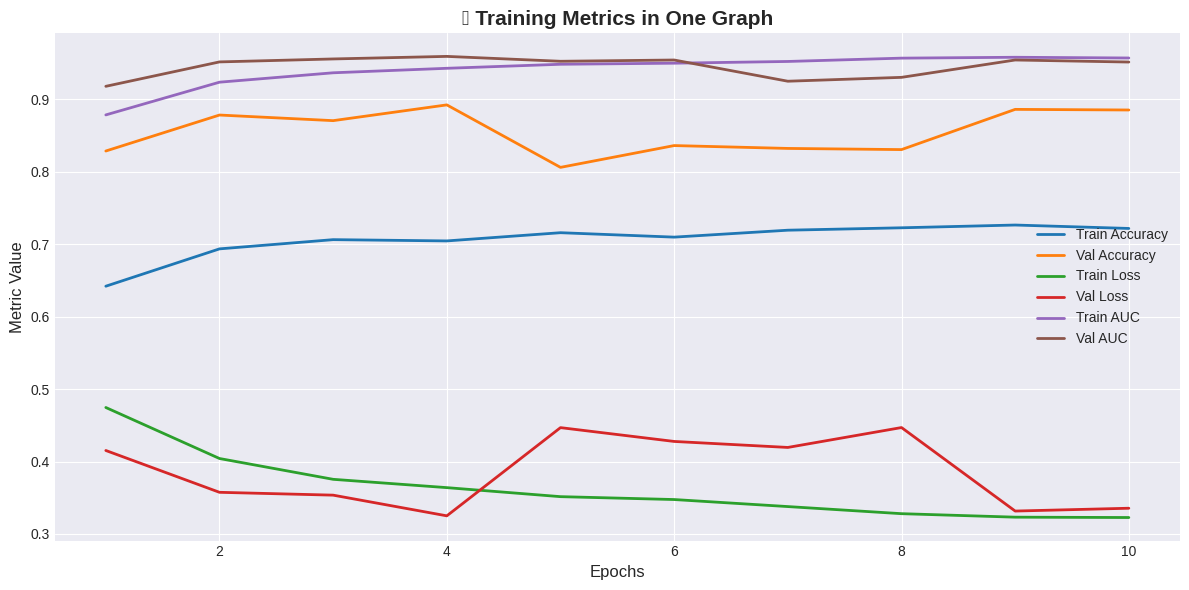

In [8]:
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-darkgrid")

history_dict = history.history
epochs = range(1, len(history_dict["loss"]) + 1)

plt.figure(figsize=(12, 6))

# Plot Accuracy
plt.plot(epochs, history_dict["accuracy"], label="Train Accuracy", linewidth=2)
plt.plot(epochs, history_dict["val_accuracy"], label="Val Accuracy", linewidth=2)

# Plot Loss
plt.plot(epochs, history_dict["loss"], label="Train Loss", linewidth=2)
plt.plot(epochs, history_dict["val_loss"], label="Val Loss", linewidth=2)

# Plot AUC
plt.plot(epochs, history_dict["auc"], label="Train AUC", linewidth=2)
plt.plot(epochs, history_dict["val_auc"], label="Val AUC", linewidth=2)

plt.title("📊 Training Metrics in One Graph", fontsize=15, fontweight="bold")
plt.xlabel("Epochs", fontsize=12)
plt.ylabel("Metric Value", fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()
